In [149]:
import pandas as pd
import matplotlib.pyplot as plt 

In [150]:
inventory_df = pd.read_csv('O:/Northwood/Capstone/bookstore_datasets/SQL DATA CLEANING/INV_STORE_LEVEL_WEIGHTED_AVG_PRICES.csv')
inventory_df.head()

,month,store_id,total_qty,wavg_unit_price
0,2019-01-01,YYC-DT,1361,26.92
1,2019-01-01,YYC-SE,784,26.71
2,2019-01-01,YYC-NW,891,26.88
3,2019-02-01,YYC-NW,1021,26.61
4,2019-02-01,YYC-SE,830,26.43


In [151]:
sales_df = pd.read_csv('O:/Northwood/Capstone/bookstore_datasets/SQL DATA CLEANING/Store_Level_SALE_Revenue.csv')
sales_df.head()

,date,store_id,revenue,net_revenue
0,2019-01-01,YYC-DT,69168.72,65710.28
1,2019-01-01,YYC-NW,49112.76,46657.11
2,2019-01-01,YYC-SE,41427.57,39356.19
3,2019-02-01,YYC-DT,69355.26,65887.49
4,2019-02-01,YYC-NW,49366.72,46898.39


In [152]:
print(inventory_df.dtypes)
print(sales_df.dtypes)  

month               object
store_id            object
total_qty            int64
wavg_unit_price    float64
dtype: object
date            object
store_id        object
revenue        float64
net_revenue    float64
dtype: object


In [153]:
sales_df['date'] = pd.to_datetime(sales_df['date']) 
inventory_df['month'] = pd.to_datetime(inventory_df['month']) 

In [154]:
print(inventory_df.dtypes)
print(sales_df.dtypes)  

month              datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object
date           datetime64[ns]
store_id               object
revenue               float64
net_revenue           float64
dtype: object


In [155]:
# Makes first date to be the First Day of the Month
sales_df['date'] = sales_df['date'].dt.to_period('M').dt.to_timestamp()
inventory_df['month'] = inventory_df['month'].dt.to_period('M').dt.to_timestamp()

In [156]:
inventory_df.dtypes

month              datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object

In [157]:
inventory_df = inventory_df.rename(columns={'month': 'date'})   
inventory_df.dtypes

date               datetime64[ns]
store_id                   object
total_qty                   int64
wavg_unit_price           float64
dtype: object

In [158]:
inventory_df['date'] = inventory_df['date'].dt.to_period('M').dt.to_timestamp()

### Checking Date Accuracies Before Joining

In [159]:
print(sales_df['date'].head(10))
print(inventory_df['date'].head(10))    

0   2019-01-01
1   2019-01-01
2   2019-01-01
3   2019-02-01
4   2019-02-01
5   2019-02-01
6   2019-03-01
7   2019-03-01
8   2019-03-01
9   2019-04-01
Name: date, dtype: datetime64[ns]
0   2019-01-01
1   2019-01-01
2   2019-01-01
3   2019-02-01
4   2019-02-01
5   2019-02-01
6   2019-03-01
7   2019-03-01
8   2019-03-01
9   2019-04-01
Name: date, dtype: datetime64[ns]


#### Ensuring Tables contain same amount of rows

In [160]:
print(sales_df.shape)
print(inventory_df.shape)     

(216, 4)
(216, 4)


In [161]:
joined_df = pd.merge(sales_df, inventory_df, on=['store_id', 'date'], how='inner')
joined_df.head(10)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20


#### Verifying Merge and Checking for Null Values

In [162]:
print(joined_df.shape)
print(joined_df.isnull().sum())

(216, 6)
date               0
store_id           0
revenue            0
net_revenue        0
total_qty          0
wavg_unit_price    0
dtype: int64


In [163]:
import numpy as np

In [164]:
# Calculate units sold
# Alternate line joined_df['units_sold'] = (joined_df['net_revenue'] / joined_df['wavg_unit_price']).astype(int)
joined_df['units_sold'] = np.floor(joined_df['net_revenue'] / joined_df['wavg_unit_price'])
joined_df.head(10)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92,2440.0
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88,1735.0
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71,1473.0
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30,2505.0
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61,1762.0
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43,1493.0
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24,3071.0
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27,2187.0
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05,1861.0
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20,3098.0


In [165]:
joined_df['MOS'] = joined_df["total_qty"] / joined_df['units_sold']
joined_df.head(10)  

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,MOS
0,2019-01-01,YYC-DT,69168.72,65710.28,1361,26.92,2440.0,0.557787
1,2019-01-01,YYC-NW,49112.76,46657.11,891,26.88,1735.0,0.513545
2,2019-01-01,YYC-SE,41427.57,39356.19,784,26.71,1473.0,0.532247
3,2019-02-01,YYC-DT,69355.26,65887.49,1601,26.30,2505.0,0.639122
4,2019-02-01,YYC-NW,49366.72,46898.39,1021,26.61,1762.0,0.579455
5,2019-02-01,YYC-SE,41544.95,39467.69,830,26.43,1493.0,0.555928
6,2019-03-01,YYC-DT,84828.12,80586.71,1667,26.24,3071.0,0.542820
7,2019-03-01,YYC-NW,60476.85,57453.02,1067,26.27,2187.0,0.487883
8,2019-03-01,YYC-SE,51057.33,48504.47,879,26.05,1861.0,0.472327
9,2019-04-01,YYC-DT,85454.76,81182.01,1721,26.20,3098.0,0.555520


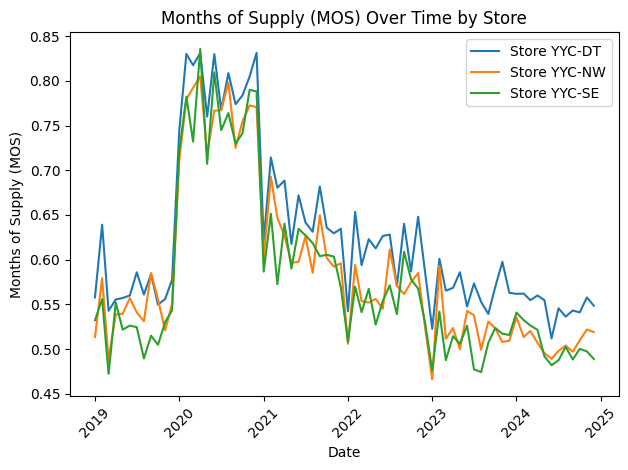

In [166]:
#Plot

plt.figure()
for store in joined_df['store_id'].unique():
    store_data = joined_df[joined_df['store_id'] == store]
    plt.plot(store_data['date'], store_data['MOS'], label=f'Store {store}')

plt.xlabel('Date')
plt.ylabel('Months of Supply (MOS)')
plt.title('Months of Supply (MOS) Over Time by Store')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Analysis of MOS
There is an issue as the bookstores are 'HEAVILY UNDERSTOCKED' at the moment
- What was not accounted for was previous stock as the total_qty only accounts for incoming stock and not what may have already been previously in the store
- Understocked is stores with a MOS < 1
- Properly Stocked or Healthy  MOS ~ 1 - 2
- Overstocked MOS > 3

### Cumulative Inventory
Determining Previous Stock

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Merged Datasets Again
merged_df = pd.merge(sales_df, inventory_df, on=['store_id', 'date'], how='inner')


In [168]:
## Trying to filter first may need to delete
merged_df = merged_df[merged_df['date'] >= '2021-01-01']

merged_df = merged_df.reset_index(drop=True)

In [169]:
# Units Sold Calculation
merged_df['units_sold'] = np.floor(merged_df['net_revenue'] / merged_df['wavg_unit_price'])
merged_df.head()

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0
1,2021-01-01,YYC-NW,42090.52,39985.98,913,26.35,1517.0
2,2021-01-01,YYC-SE,35663.93,33880.70,765,25.98,1304.0
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0
4,2021-02-01,YYC-NW,42214.89,40104.17,1087,25.56,1569.0


In [170]:
# Sorting by date
merged_df = merged_df.sort_values(['store_id', 'date'])

In [171]:
## Initializing a Running Inventory Column
merged_df['running_inventory'] = 0.0

In [172]:
## Applying for each store

for store in merged_df['store_id'].unique():
    store_data = merged_df[merged_df['store_id'] == store]
    previous_inventory = 4000.0
    runnning = []
    for index, row in store_data.iterrows():
        current_inventory = previous_inventory + row['total_qty'] - row['units_sold']
        runnning.append(current_inventory)
        previous_inventory = current_inventory
    merged_df.loc[store_data.index, 'running_inventory'] = runnning


In [173]:
merged_df["MOS"] = merged_df['running_inventory'] / merged_df['units_sold']

merged_df["MOS"] = np.floor(merged_df["MOS"])
merged_df.head(5)

,date,store_id,revenue,net_revenue,total_qty,wavg_unit_price,units_sold,running_inventory,MOS
0,2021-01-01,YYC-DT,59255.13,56292.39,1344,26.01,2164.0,3180.0,1.0
3,2021-02-01,YYC-DT,60306.40,57291.07,1580,25.89,2212.0,2548.0,1.0
6,2021-03-01,YYC-DT,70983.10,67433.94,1725,26.60,2535.0,1738.0,0.0
9,2021-04-01,YYC-DT,72715.28,69079.51,1834,25.93,2664.0,908.0,0.0
12,2021-05-01,YYC-DT,77987.76,74088.37,1747,26.18,2829.0,-174.0,-1.0


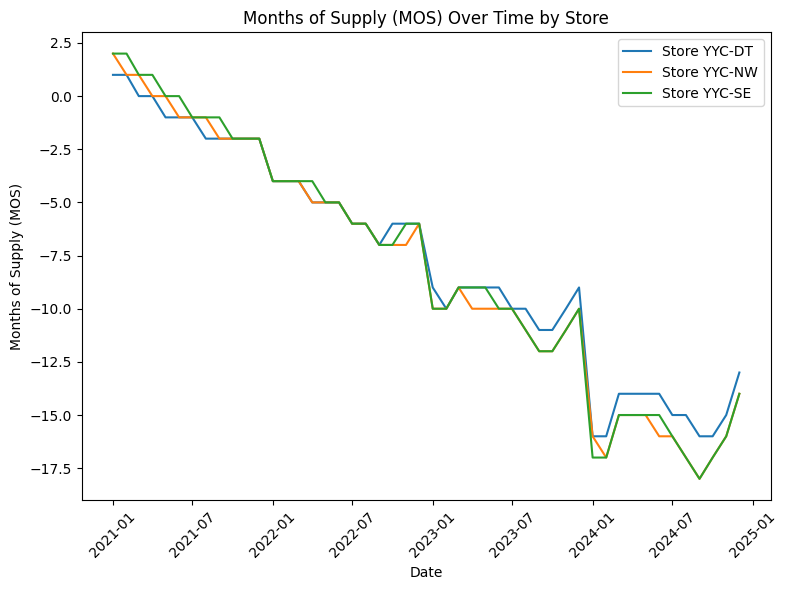

In [174]:
plt.figure(figsize=(8,6))
for store in merged_df['store_id'].unique():
    store_data = merged_df[merged_df['store_id'] == store]
    plt.plot(store_data['date'], store_data['MOS'], label=f'Store {store}')

plt.xlabel('Date')
plt.ylabel('Months of Supply (MOS)')
plt.title('Months of Supply (MOS) Over Time by Store')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Concluding Statements
- Each Store is running into stockouts
- Cumulative Inventory did not make for a better supply and or MOS
- Looking at Month by Month determined a better analysis
- Customers could be ordering online
- Stores are missing out on Sales due to stockouts